**Author:** Christopher Millward<br>
**Date:** August 14, 2026

The purpose of this notebook is to determine how far off the single trace total calculation is from the sum of the trace calculations performed in the bin totals. If they are dramatically different, I will have to figure out why and decide an appropriate path.

---

Steps:
1. Create table with trace_total and bin_total for each participant. 
2. Perform t-test to see if they are statistically different.
3. Visualize absolute and normalized differences.

In [1]:
import os 
import sys

# set root folder to project root
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# auto reload
%load_ext autoreload
%autoreload 2

## 1. Create table with trace_total and bin_total for each participant.

In [2]:
import pickle
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt


from config import RESULTS_PICKLE_PATH
from schema import ParticipantDetails

In [3]:
# import pickle file
with open(Path(RESULTS_PICKLE_PATH), 'rb') as f:
    results: list[ParticipantDetails] = pickle.load(f)

# create table with participant_side, trace_total, bin_total
rows = []
for idx, participant in enumerate(results):
    for side in ['left', 'right']:
        side_data = getattr(participant, side)
        vals = {
            'participant_side': f"{participant.filename}_{side}",
            'trace_total': side_data.humerothoracic.trace_total,
            'bin_total': side_data.humerothoracic.heatmap.cumulative_motion.sum()
        }
        rows.append(vals)

df = pd.DataFrame(rows)

## 2. Perform t-test to see if they are statistically different.

In [4]:
t_stat, p_value = stats.ttest_rel(df['trace_total'], df['bin_total'])

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.2e}")  

T-statistic: -1.39
P-value: 1.71e-01


## 3. Visualize absolute and normalized differences.

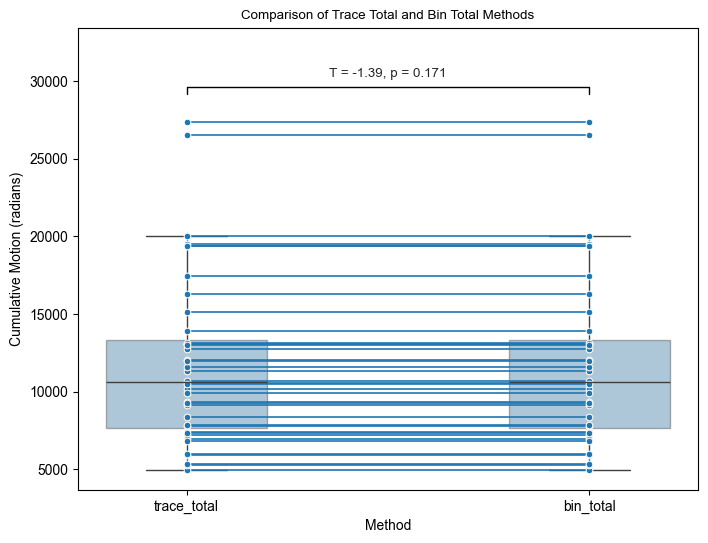

In [5]:
# --------------------------------------------------
# Prep Data
# --------------------------------------------------
plot_data = df.melt(
    id_vars="participant_side",
    value_vars=["trace_total", "bin_total"],
    var_name="method",
    value_name="total",
)


# --------------------------------------------------
# Plot Data
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
sns.set_theme(context="paper", style="whitegrid")

# Boxplots
sns.boxplot(
    data=plot_data,
    x="method",
    y="total",
    width=0.4,
    showfliers=False,
    boxprops={"alpha": 0.4},
    ax=ax,
)

# Paired observations
sns.lineplot(
    data=plot_data,
    x="method",
    y="total",
    units="participant_side",
    estimator=None,
    marker="o",
    ax=ax,
)

ax.set_title("Comparison of Trace Total and Bin Total Methods")
ax.set_ylabel("Cumulative Motion (radians)")
ax.set_xlabel("Method")


# --------------------------------------------------
# Statistical annotation
# --------------------------------------------------
y_max = plot_data["total"].max()
y_range = plot_data["total"].max() - plot_data["total"].min()

bar_y = y_max + 0.08 * y_range
text_y = y_max + 0.12 * y_range
bar_height = 0.02 * y_range

# Significance bar
ax.plot(
    [0, 0, 1, 1],
    [bar_y, bar_y + bar_height, bar_y + bar_height, bar_y],
    color="black",
    linewidth=1,
)

# T-statistic and p-value
ax.text(
    0.5,
    text_y,
    f"T = {t_stat:.2f}, p = {p_value:.3g}",
    ha="center",
    va="bottom",
)

# Give annotation some room
ax.set_ylim(
    top=text_y + 0.15 * y_range,
)

plt.show()

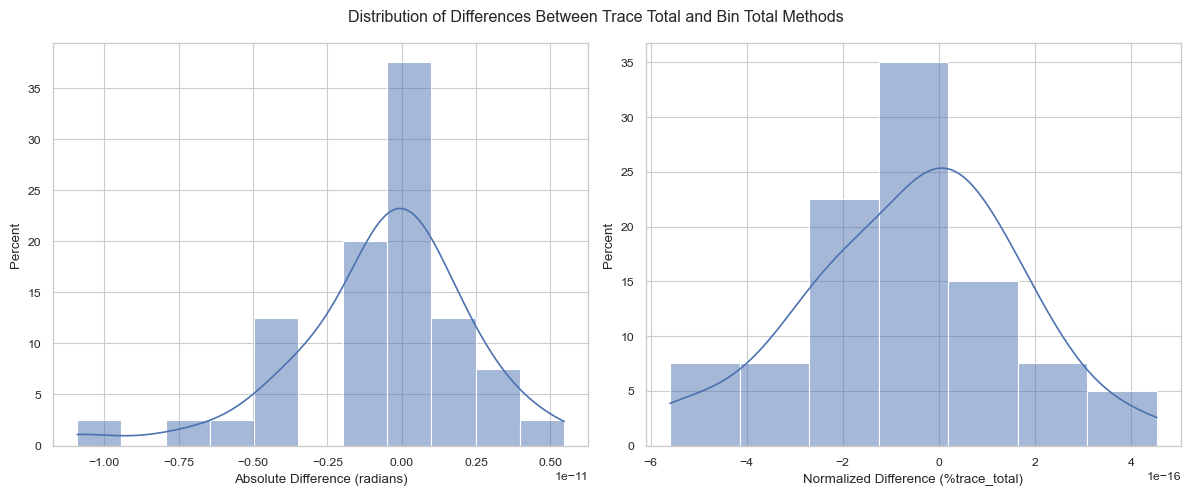

In [6]:
# Plot the differences between the two methods
# both absolute and normalized
df['difference'] = df['trace_total'] - df['bin_total']
df['normalized_difference'] = df['difference'] / df['trace_total']


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=df, 
    x="difference", 
    kde=True,
    stat="percent",
    ax=axes[0]
)
axes[0].set_xlabel("Absolute Difference (radians)")

sns.histplot(
    data=df, 
    x="normalized_difference", 
    kde=True, 
    stat="percent",
    ax=axes[1], 
)
axes[1].set_xlabel("Normalized Difference (%trace_total)")

# Optimize spacing and display
fig.suptitle("Distribution of Differences Between Trace Total and Bin Total Methods")
plt.tight_layout()
plt.show()

Though this, I realized a key difference in the underlying math: 
- **The _trace_ method** calculates the _minimum angular rotation required to transform from one orientation to the other_. So, it will simply look at the start and end orientations and determine the shortest path between the two. We do this for every time step, giving us the smallest possible rotations that occured between each sample, and then sum them, resulting in the shortest possible motion for all of the orientations observed all day.
- **The _Euler_ Method** decomposes the rotation into 3 rotations, along 2 axes (Y-X-Y). We can sum the motion along one axis to tell us how much motion occured along one axis, given our assumed decomposition, but we cannot sum all 3 axes together to give us total motion. I see this analogous to pythagorean: if we decompose a vector into x and y components and then simply sum them, we will end up with the same final destination, but a different travel length. As such, the Euler method is incorrect and should not be used to determine total overall motion. 

For now, we will stick to the trace method to calculate the total accumulated motion. We are using the Euler decomposition method to determine single-axis rotation within each bin. If, down the road, we wish to determine the total amount of motion in each bin, we will have to implement the Trace method into the bin calcs module. 
